In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())


      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [3]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34033, dtype: float64

In [4]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34033, dtype: float64

In [5]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [6]:
import numpy as np

# Define columns to check for outliers
log_cols = ['max_power', 'max_torque', 'max_engine_capacity_new', 'price']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [7]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])
df["log_km_driven"] = np.log(df["km_driven"])


In [8]:
import numpy as np

features = [
    
 "log_km_driven", "mileage_new", 
    "log_max_power", "log_max_torque",
 "log_max_engine_capacity_new"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
y = df["price"]
#y = np.log(df["price"])  # Natural logarithm (base e)

In [9]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


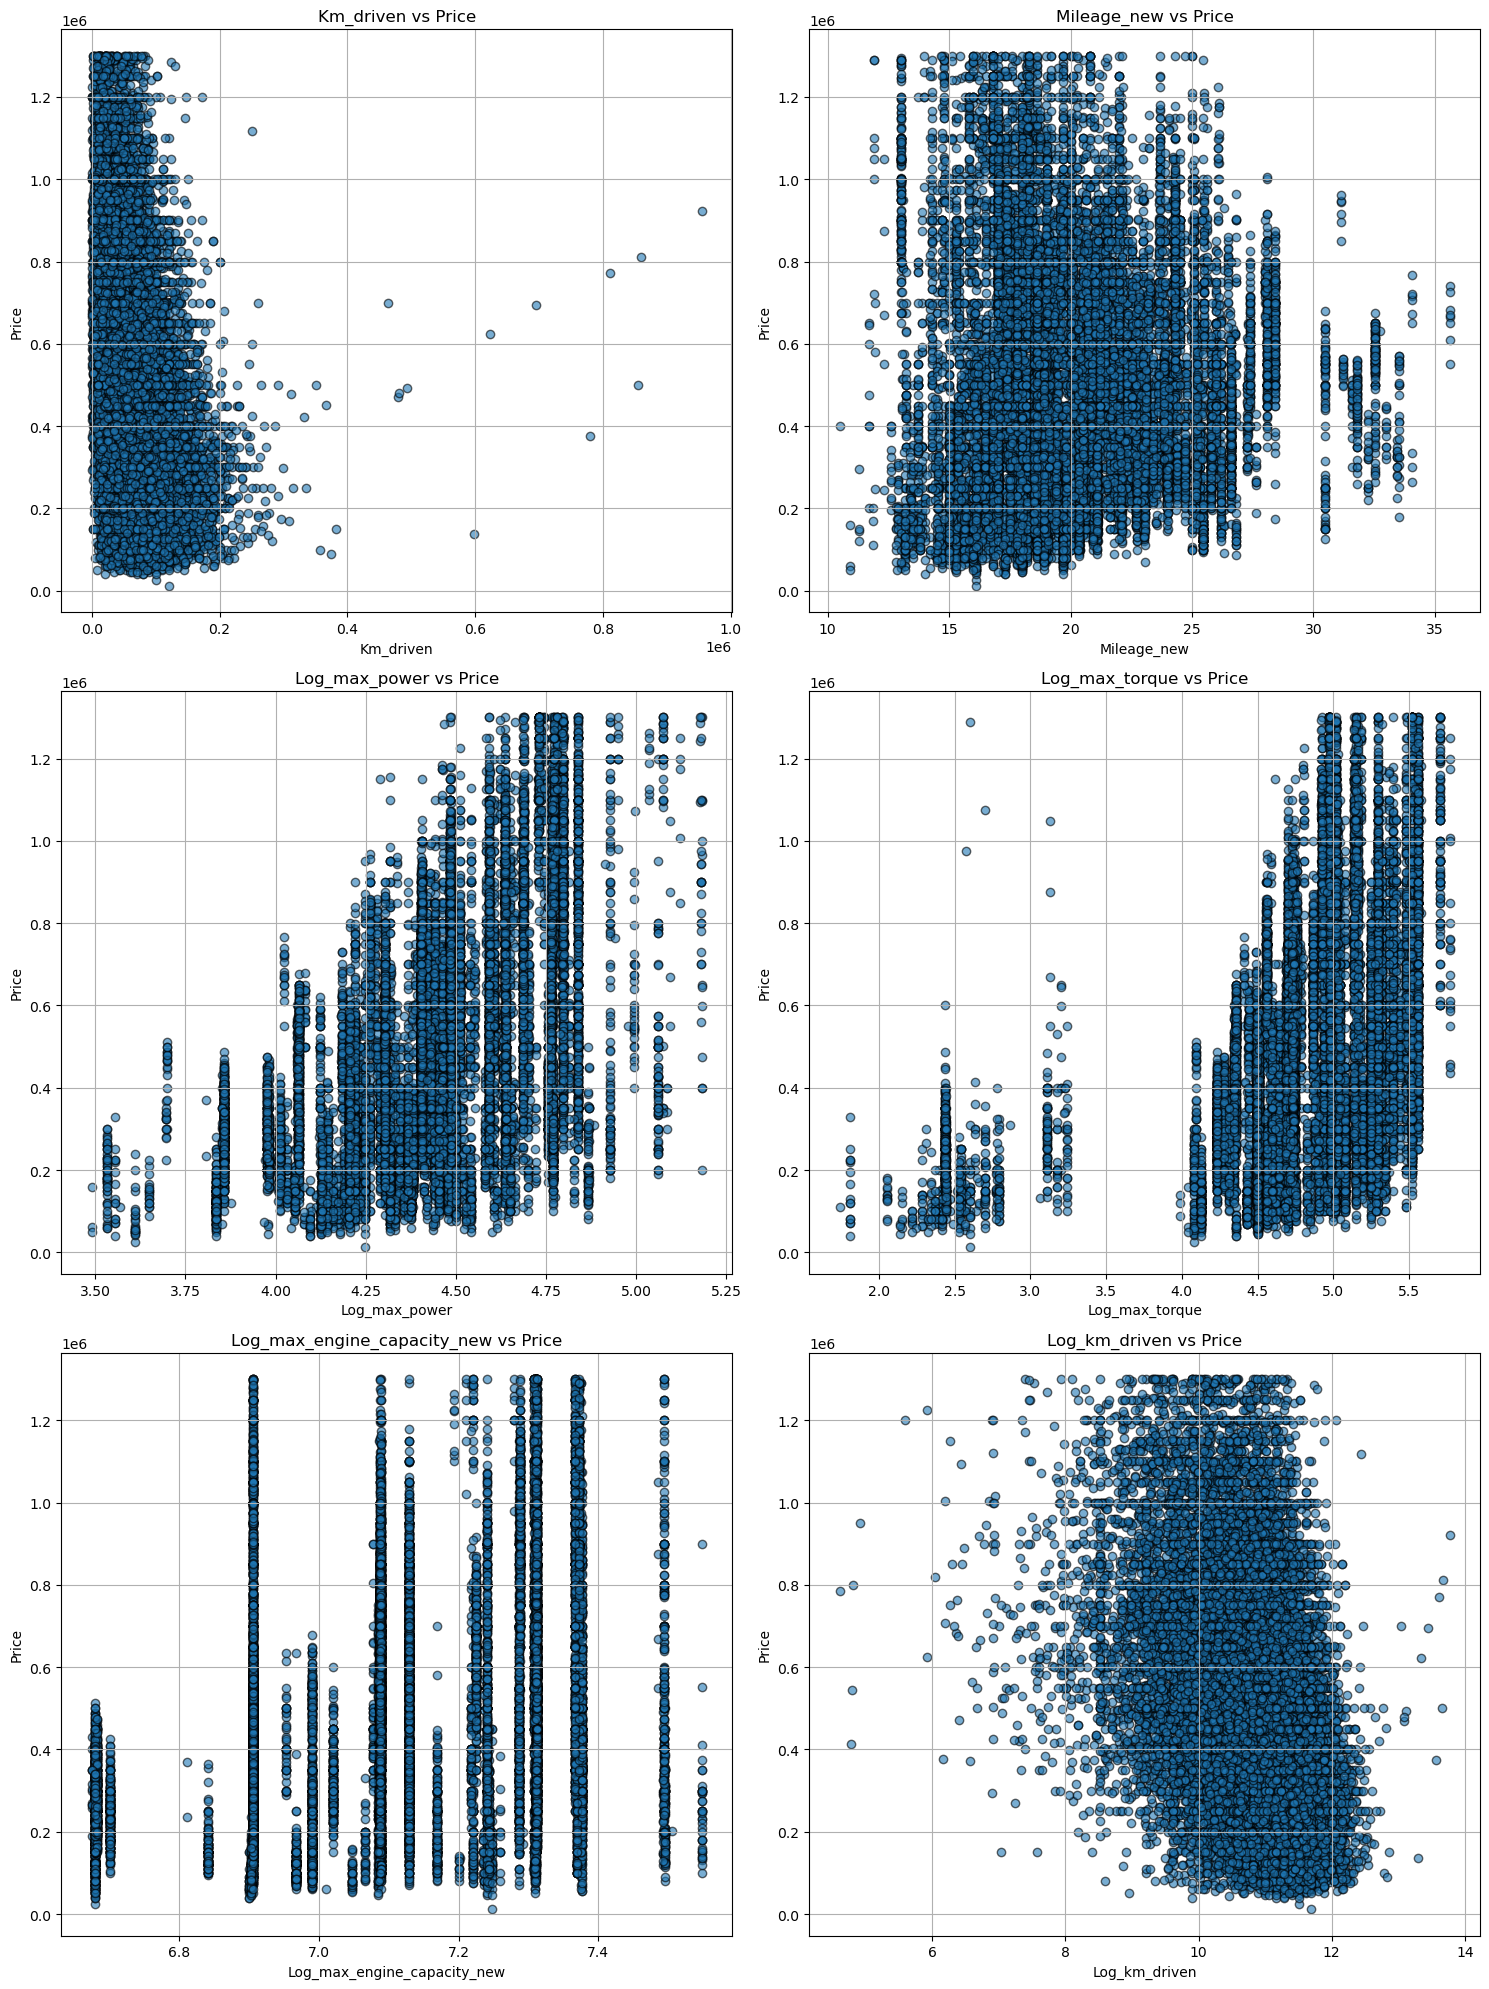

In [11]:
import matplotlib.pyplot as plt

# Example data (replace with your actual data)
variables = ["km_driven", "mileage_new", 
    "log_max_power", "log_max_torque",
 "log_max_engine_capacity_new" ,"log_km_driven"]  # Variables to plot
price_column = 'price'  # Target variable
data = df  # Ensure this is a DataFrame


# Plotting scatter plots
plt.figure(figsize=(15, 20))

for i, variable in enumerate(variables, 1):
    plt.subplot(3, 2, i)
    try:
        plt.scatter(data[variable], data[price_column], alpha=0.6, marker='o', edgecolor='k')
        plt.xlabel(variable.capitalize())
        plt.ylabel(price_column.capitalize())
        plt.title(f'{variable.capitalize()} vs {price_column.capitalize()}')
        plt.grid(True)
    except TypeError as e:
        print(f"Could not plot {variable} due to: {e}")

plt.tight_layout()
plt.show()


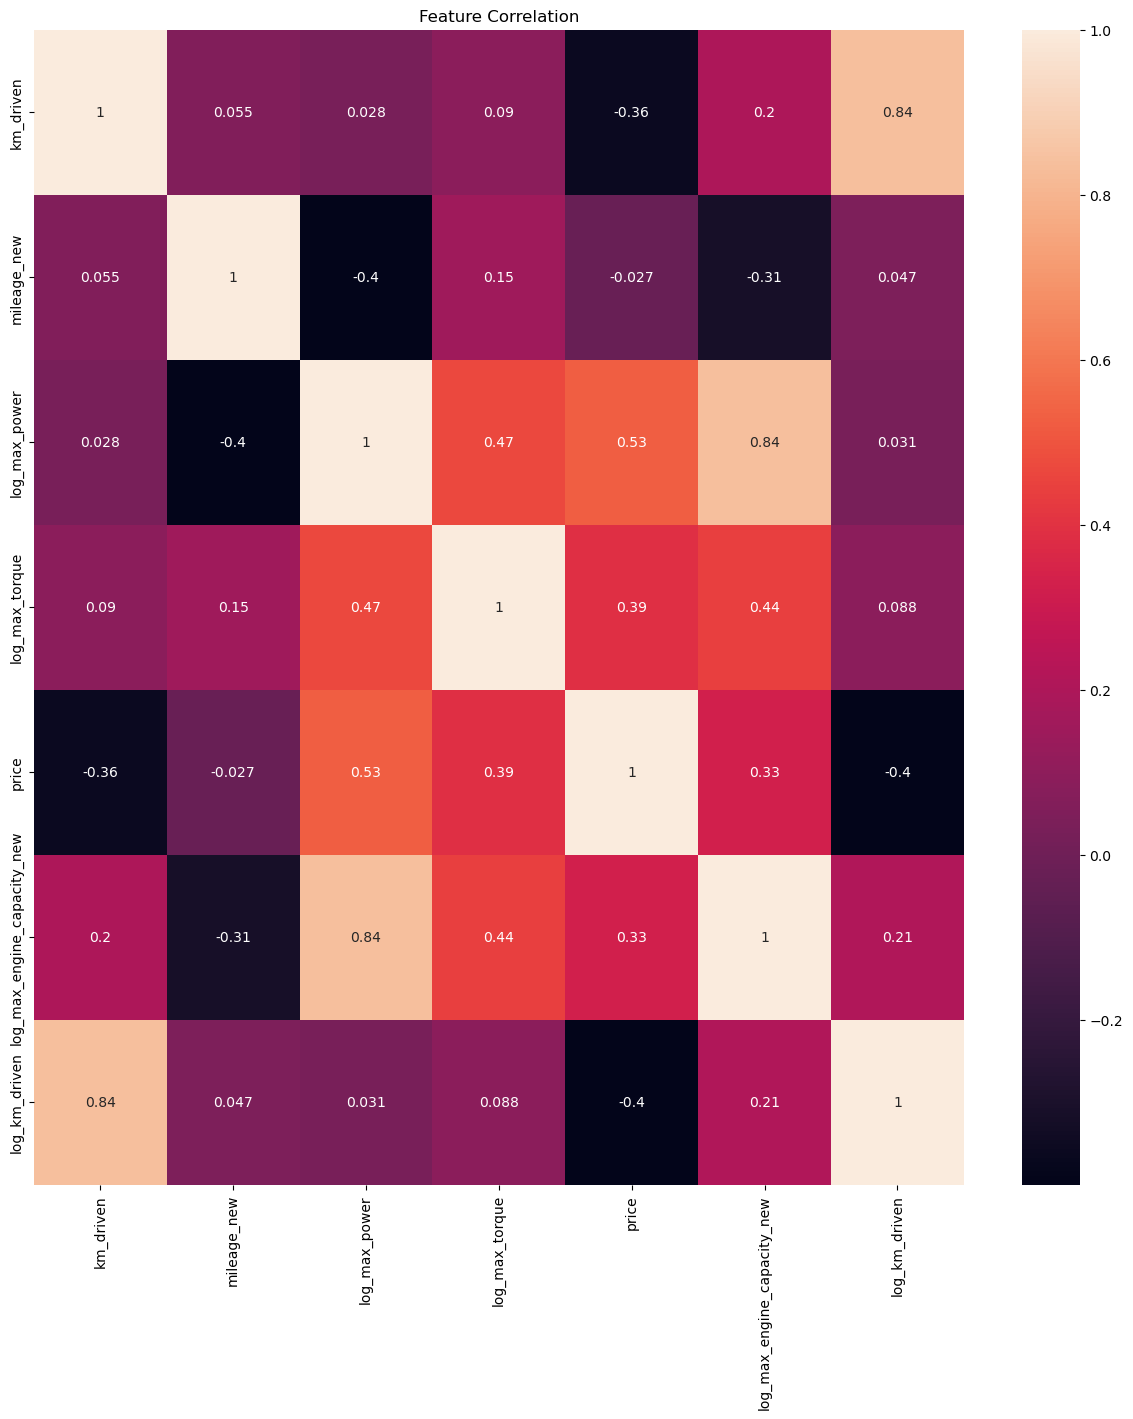

In [12]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new", "log_km_driven"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

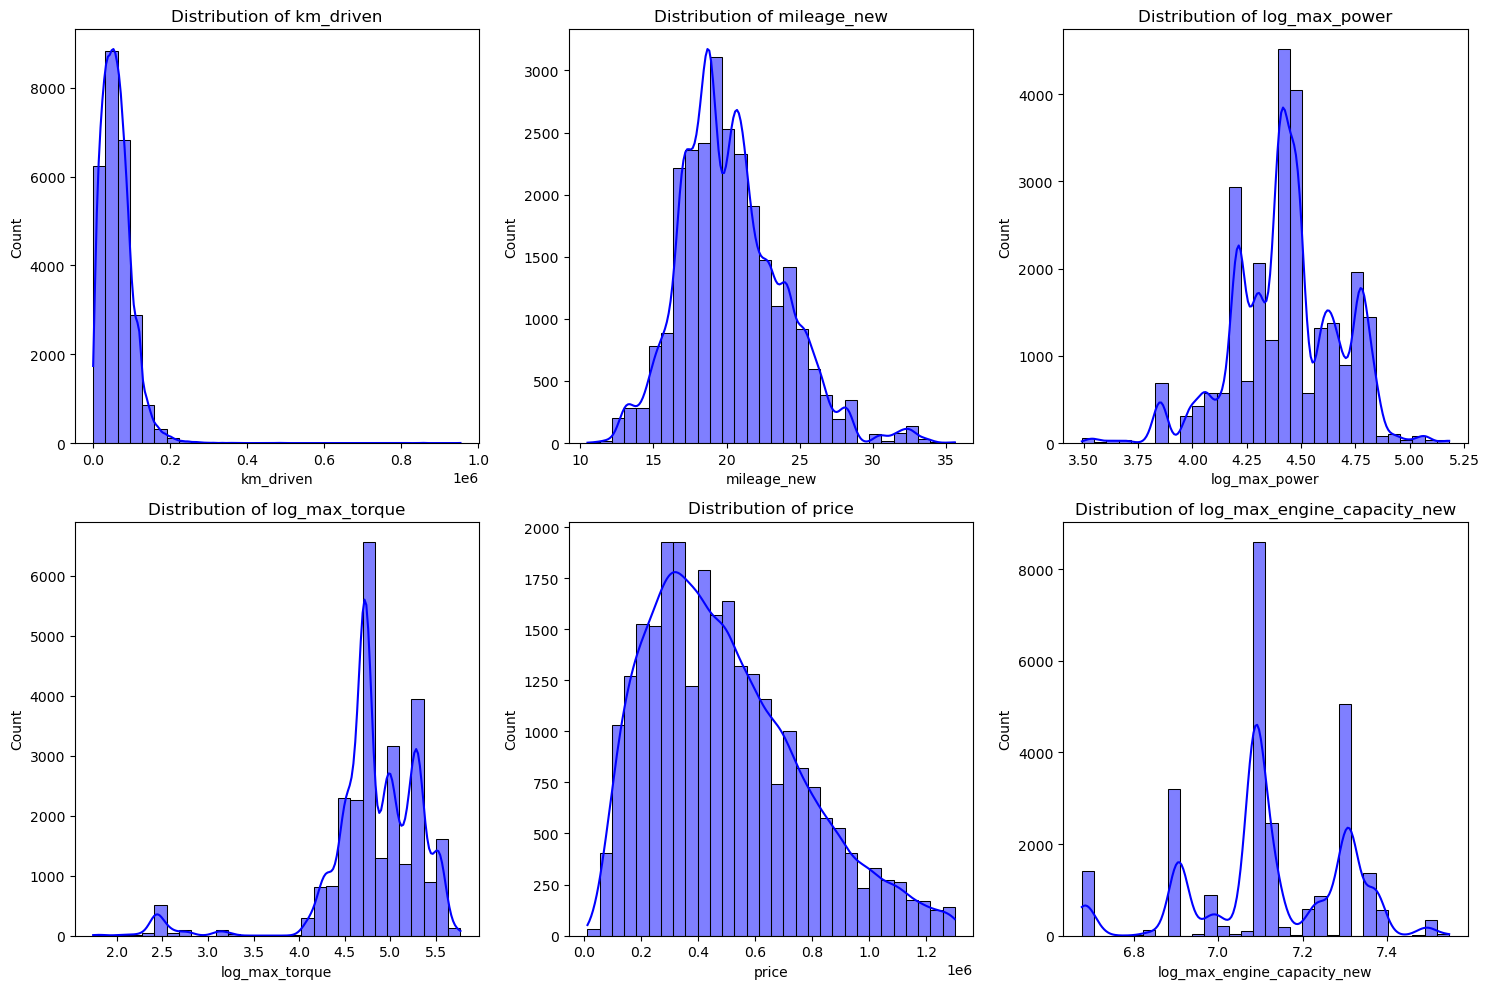

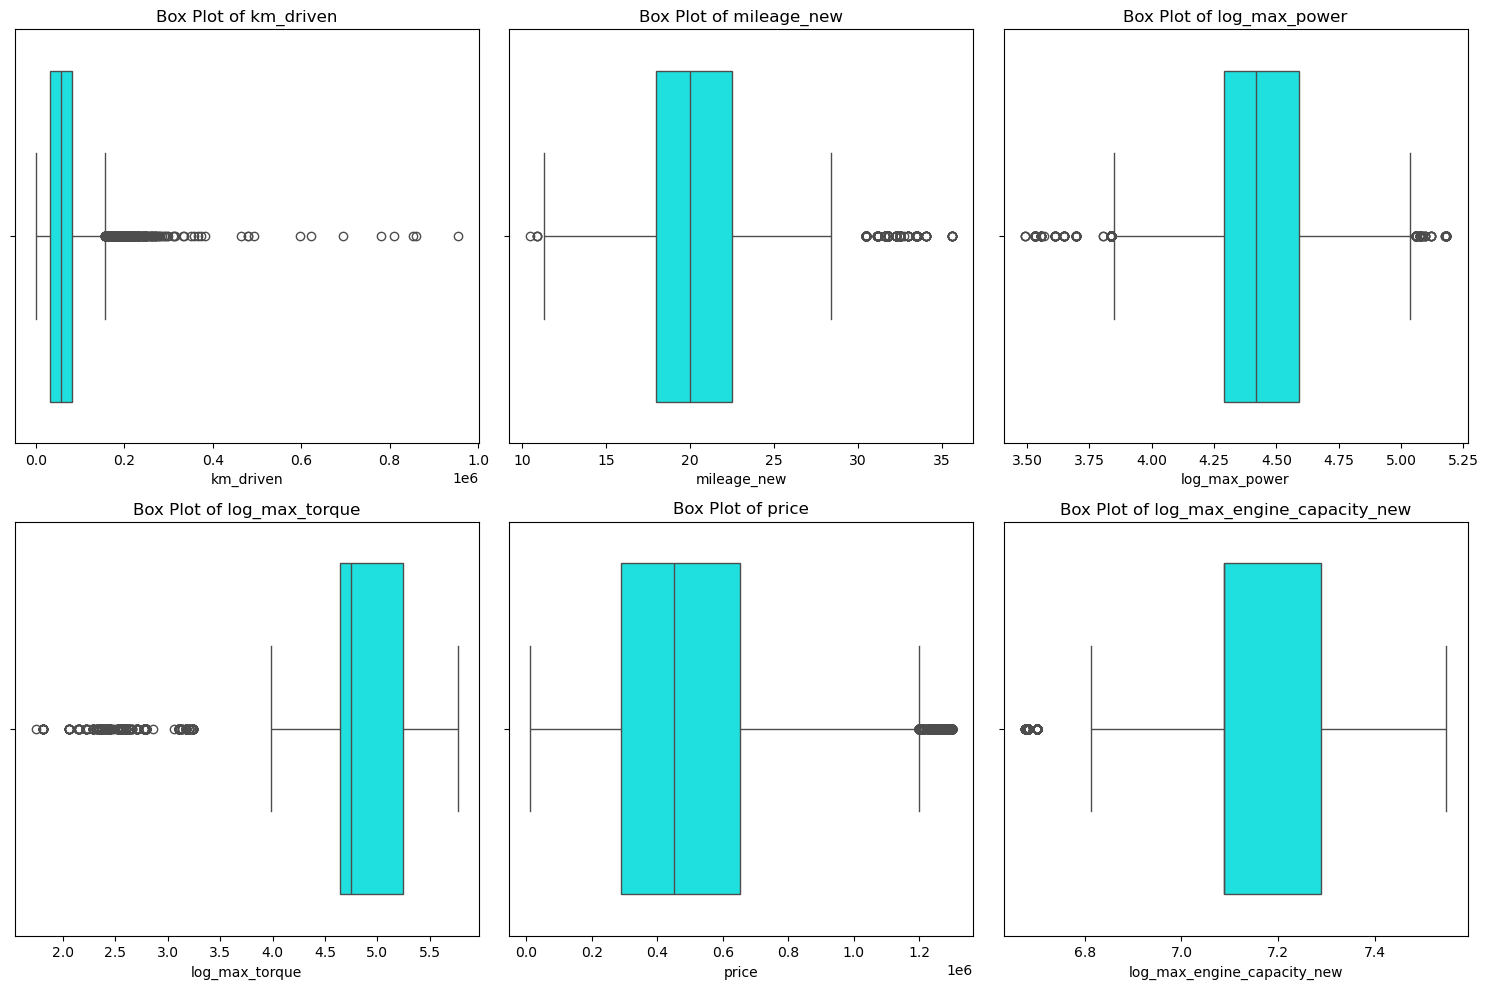

In [13]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,913 (777.00 KB)

 Trainable params: 198,913 (777.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 236682903552.0000 - mae: 403447.2188 - val_loss: 61125492736.0000 - val_mae: 200887.8594
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 60739555328.0000 - mae: 198430.2969 - val_loss: 56544047104.0000 - val_mae: 191596.1562
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 57044541440.0000 - mae: 192426.0781 - val_loss: 51602870272.0000 - val_mae: 182974.2344
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 51957714944.0000 - mae: 182908.1875 - val_loss: 45764308992.0000 - val_mae: 171443.9219
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 46249869312.0000 - mae: 171282.6875 - val_loss: 39428698112.0000 - val_mae: 158060.9375
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 39971328000.0000 - mae: 158106.1406 - val_loss: 35218915328.0000 - val_mae: 148397.1719
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 36321431552.0000 - mae: 149542.8594 - val_lo

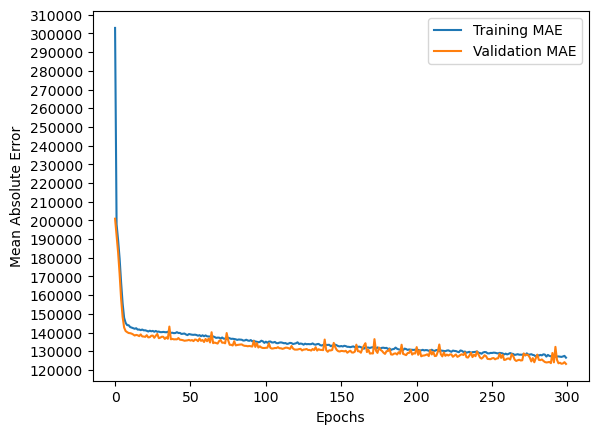

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model10 = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model10.summary()
model10.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model10.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,377 (333.50 KB)

 Trainable params: 85,377 (333.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 255404654592.0000 - mae: 424039.2812 - val_loss: 61917577216.0000 - val_mae: 199964.4531
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 63247167488.0000 - mae: 202448.4688 - val_loss: 57738297344.0000 - val_mae: 193849.2500
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 57865412608.0000 - mae: 194194.0312 - val_loss: 53521309696.0000 - val_mae: 185794.0156
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 53236133888.0000 - mae: 185459.5312 - val_loss: 49073094656.0000 - val_mae: 178952.8125
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 48169697280.0000 - mae: 175227.4219 - val_loss: 43056246784.0000 - val_mae: 165799.6719
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 42886332416.0000 - mae: 165436.2812 - val_loss: 37883514880.0000 - val_mae: 155249.1875
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 38587318272.0000 - mae: 155643.4531 - val_lo

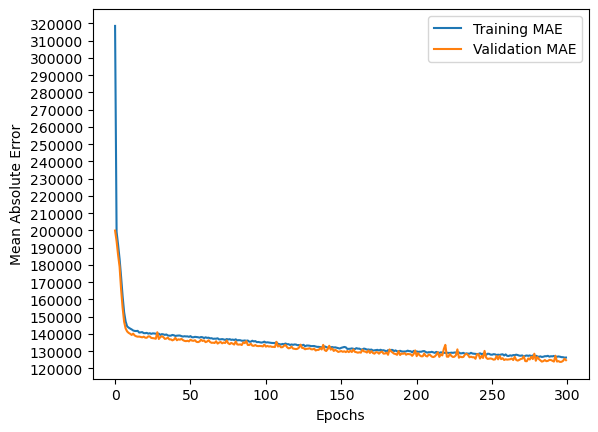

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model9 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.15),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model9.summary()
model9.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model9.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,313 (1.52 MB)

 Trainable params: 397,313 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 200377679872.0000 - mae: 361597.0000 - val_loss: 59444076544.0000 - val_mae: 198314.1406
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 58397224960.0000 - mae: 195062.8438 - val_loss: 53056999424.0000 - val_mae: 185153.2500
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 53011603456.0000 - mae: 184850.5938 - val_loss: 45135839232.0000 - val_mae: 169908.3906
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 43939278848.0000 - mae: 167591.2344 - val_loss: 36878766080.0000 - val_mae: 152617.1094
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 36428541952.0000 - mae: 149958.9844 - val_loss: 33243002880.0000 - val_mae: 143013.0938
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 34293442560.0000 - mae: 144391.9375 - val_loss: 32456159232.0000 - val_mae: 140078.0156
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 33404588032.0000 - mae: 141337.5469 - val_lo

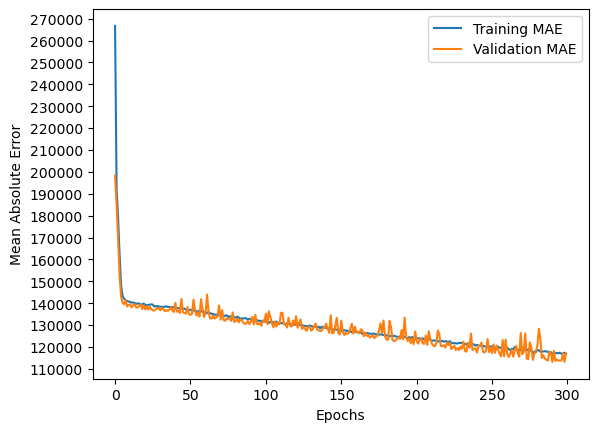

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model0 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model0.summary()
model0.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model0.fit(X_train, y_train, epochs=300, validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,897 (2.02 MB)

 Trainable params: 528,897 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 184157274112.0000 - mae: 342079.1875 - val_loss: 57644949504.0000 - val_mae: 193207.2969
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 56431443968.0000 - mae: 191736.7656 - val_loss: 49683218432.0000 - val_mae: 180546.3906
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 46148788224.0000 - mae: 171853.9219 - val_loss: 38443687936.0000 - val_mae: 156430.0938
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 36476825600.0000 - mae: 151354.4531 - val_loss: 33269950464.0000 - val_mae: 143212.7656
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 33329967104.0000 - mae: 142751.9062 - val_loss: 33358540800.0000 - val_mae: 141919.4688
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 33255667712.0000 - mae: 141355.7656 - val_loss: 32680046592.0000 - val_mae: 139954.9531
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 32512329728.0000 - mae: 140100.2188 - val_lo

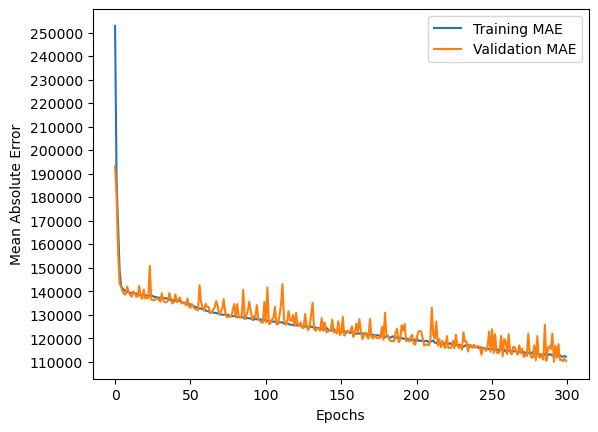

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model8 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model8.summary()
model8.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model8.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,409 (68.00 KB)

 Trainable params: 17,409 (68.00 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model1.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))

Epoch 1/300


654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 34428346368.0000 - mae: 142911.7188 - val_loss: 32137791488.0000 - val_mae: 138082.3750
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 35151765504.0000 - mae: 143885.9219 - val_loss: 32125988864.0000 - val_mae: 138038.6719
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 34808205312.0000 - mae: 143668.1875 - val_loss: 32106506240.0000 - val_mae: 137937.5469
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 34409799680.0000 - mae: 142064.2656 - val_loss: 32114268160.0000 - val_mae: 137928.0312
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 34823516160.0000 - mae: 142695.0469 - val_loss: 32167591936.0000 - val_mae: 137994.6250
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 34458775552.0000 - mae: 142857.4531 - val_loss: 32106981376.0000 - val_mae: 137913.9844
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 34550112256.0000 - mae: 142966.5000 - val_loss: 321067376

KeyboardInterrupt: 

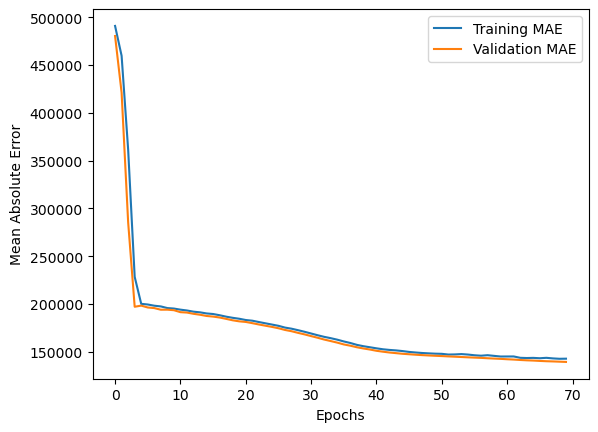

In [ ]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

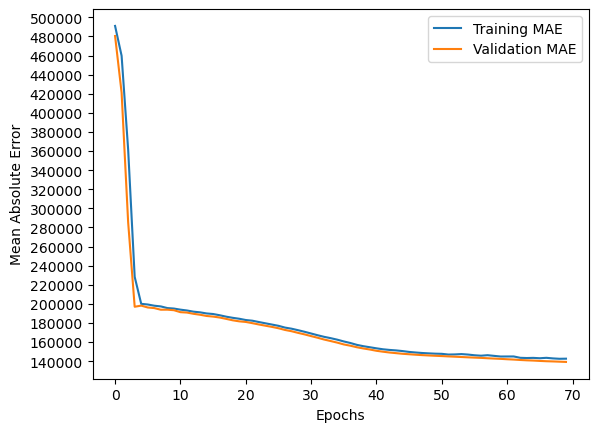

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(1)
])
model3.summary()
model3.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,601 (100.00 KB)

 Trainable params: 25,601 (100.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model3.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

Epoch 1/300


654/654 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 263305920512.0000 - mae: 433500.3125 - val_loss: 62723629056.0000 - val_mae: 201582.9688
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 64213725184.0000 - mae: 204339.7031 - val_loss: 60639948800.0000 - val_mae: 199518.1719
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 62384189440.0000 - mae: 201581.6406 - val_loss: 58508726272.0000 - val_mae: 195529.1875
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 60901978112.0000 - mae: 198600.7500 - val_loss: 56282333184.0000 - val_mae: 190946.1406
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 57453314048.0000 - mae: 191609.1094 - val_loss: 53816016896.0000 - val_mae: 186762.1094
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 55404445696.0000 - mae: 188681.1250 - val_loss: 51086884864.0000 - val_mae: 181787.3906
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 52568694784.0000 - mae: 183353.1406 - val_loss: 48005173

KeyboardInterrupt: 

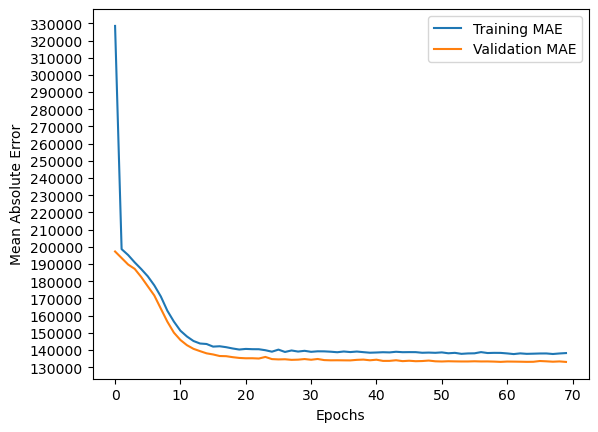

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model4 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(127, activation="relu"),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model4.summary()
model4.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 127)            │        32,639 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 127)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,296 (684.75 KB)

 Trainable params: 175,296 (684.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model4.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 175854927872.0000 - mae: 333657.7500 - val_loss: 57008619520.0000 - val_mae: 192456.0312
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 57349644288.0000 - mae: 192464.5312 - val_loss: 45330247680.0000 - val_mae: 170715.6562
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 43503648768.0000 - mae: 165244.5781 - val_loss: 33568364544.0000 - val_mae: 144361.2969
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 36051091456.0000 - mae: 147304.3125 - val_loss: 33393917952.0000 - val_mae: 141740.7344
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 35490721792.0000 - mae: 145701.1875 - val_loss: 32169846784.0000 - val_mae: 139074.6250
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 35129962496.0000 - mae: 145194.0156 - val_loss: 32194430976.0000 - val_mae: 138404.6719
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 35106406400.0000 - mae: 144102.2344 - val_lo

KeyboardInterrupt: 

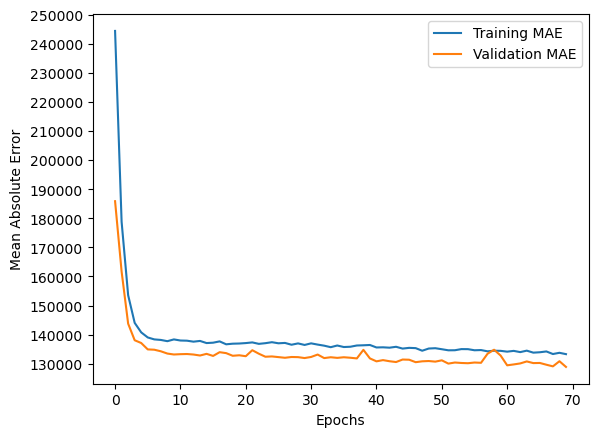

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(1)
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,353 (454.50 KB)

 Trainable params: 116,353 (454.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:

history = model5.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=20)  # Increase nbins for more ticks

plt.show()

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 171177574400.0000 - mae: 328189.3125 - val_loss: 57130479616.0000 - val_mae: 192381.4219
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 56776204288.0000 - mae: 191636.4531 - val_loss: 49881735168.0000 - val_mae: 176314.4062
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47639699456.0000 - mae: 173449.0625 - val_loss: 36098338816.0000 - val_mae: 150292.0156
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 37893152768.0000 - mae: 151412.2031 - val_loss: 32684025856.0000 - val_mae: 140643.3281
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 35282804736.0000 - mae: 145367.5312 - val_loss: 32033656832.0000 - val_mae: 138217.5156
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 35850678272.0000 - mae: 145129.9375 - val_loss: 33012916224.0000 - val_mae: 140681.0625
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 34868207616.0000 - mae: 143786.7500 - val_lo

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 288527220736.0000 - mae: 464635.3750 - val_loss: 60661547008.0000 - val_mae: 197651.7344
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 62860062720.0000 - mae: 201337.0625 - val_loss: 58050482176.0000 - val_mae: 194995.6250
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58882895872.0000 - mae: 194636.3125 - val_loss: 55842643968.0000 - val_mae: 190051.1406
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 57320824832.0000 - mae: 192714.1094 - val_loss: 53485522944.0000 - val_mae: 186633.3125
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54671958016.0000 - mae: 187405.0781 - val_loss: 51018792960.0000 - val_mae: 181655.7344
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 52686561280.0000 - mae: 183436.0469 - val_loss: 48192450560.0000 - val_mae: 175979.9844
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49125462016.0000 - mae: 176948.5625 - val_loss: 450

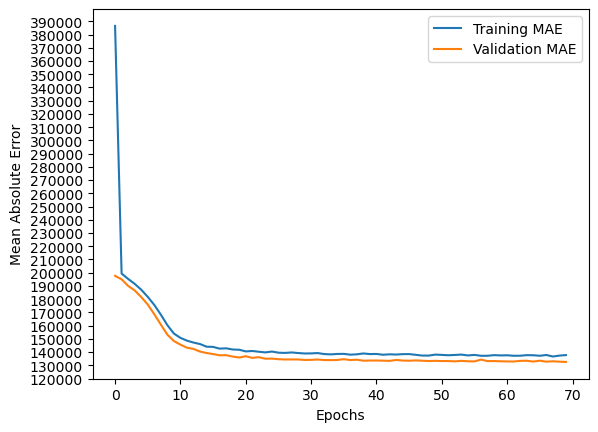

In [ ]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model6 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model6.summary()
model6.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 289858191360.0000 - mae: 465232.4688 - val_loss: 60698279936.0000 - val_mae: 197324.5312
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 63122558976.0000 - mae: 203546.7344 - val_loss: 58000728064.0000 - val_mae: 194017.6250
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 58552262656.0000 - mae: 194594.7031 - val_loss: 55923302400.0000 - val_mae: 192303.5469
Epoch 4/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56480378880.0000 - mae: 191593.4375 - val_loss: 53531672576.0000 - val_mae: 186440.1250
Epoch 5/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54364794880.0000 - mae: 187228.4219 - val_loss: 51131514880.0000 - val_mae: 181970.2031
Epoch 6/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51908374528.0000 - mae: 183112.7188 - val_loss: 48421965824.0000 - val_mae: 176762.7656
Epoch 7/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48429010944.0000 - mae: 175593.7656 - val_loss: 452

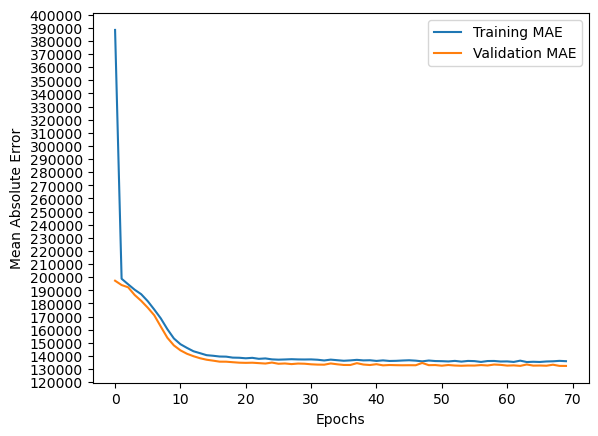

In [ ]:
history = model6.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))
import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model7 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model7.summary()
model7.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model7.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,409 (68.00 KB)

 Trainable params: 17,409 (68.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 316493955072.0000 - mae: 495042.0625 - val_loss: 304661954560.0000 - val_mae: 483865.8750
Epoch 2/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 303529361408.0000 - mae: 481143.2188 - val_loss: 265202548736.0000 - val_mae: 442488.2500
Epoch 3/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 248599052288.0000 - mae: 422200.1875 - val_loss: 179770605568.0000 - val_mae: 339527.8125
Epoch 4/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 155591409664.0000 - mae: 307325.8125 - val_loss: 82210275328.0000 - val_mae: 215238.6406
Epoch 5/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 69987729408.0000 - mae: 202500.6562 - val_loss: 60256460800.0000 - val_mae: 198453.0312
Epoch 6/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 60902707200.0000 - mae: 199194.7812 - val_loss: 59657560064.0000 - val_mae: 197526.9531
Epoch 7/300
654/654 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 60055732224.0000 - mae: 198104.9531 - 

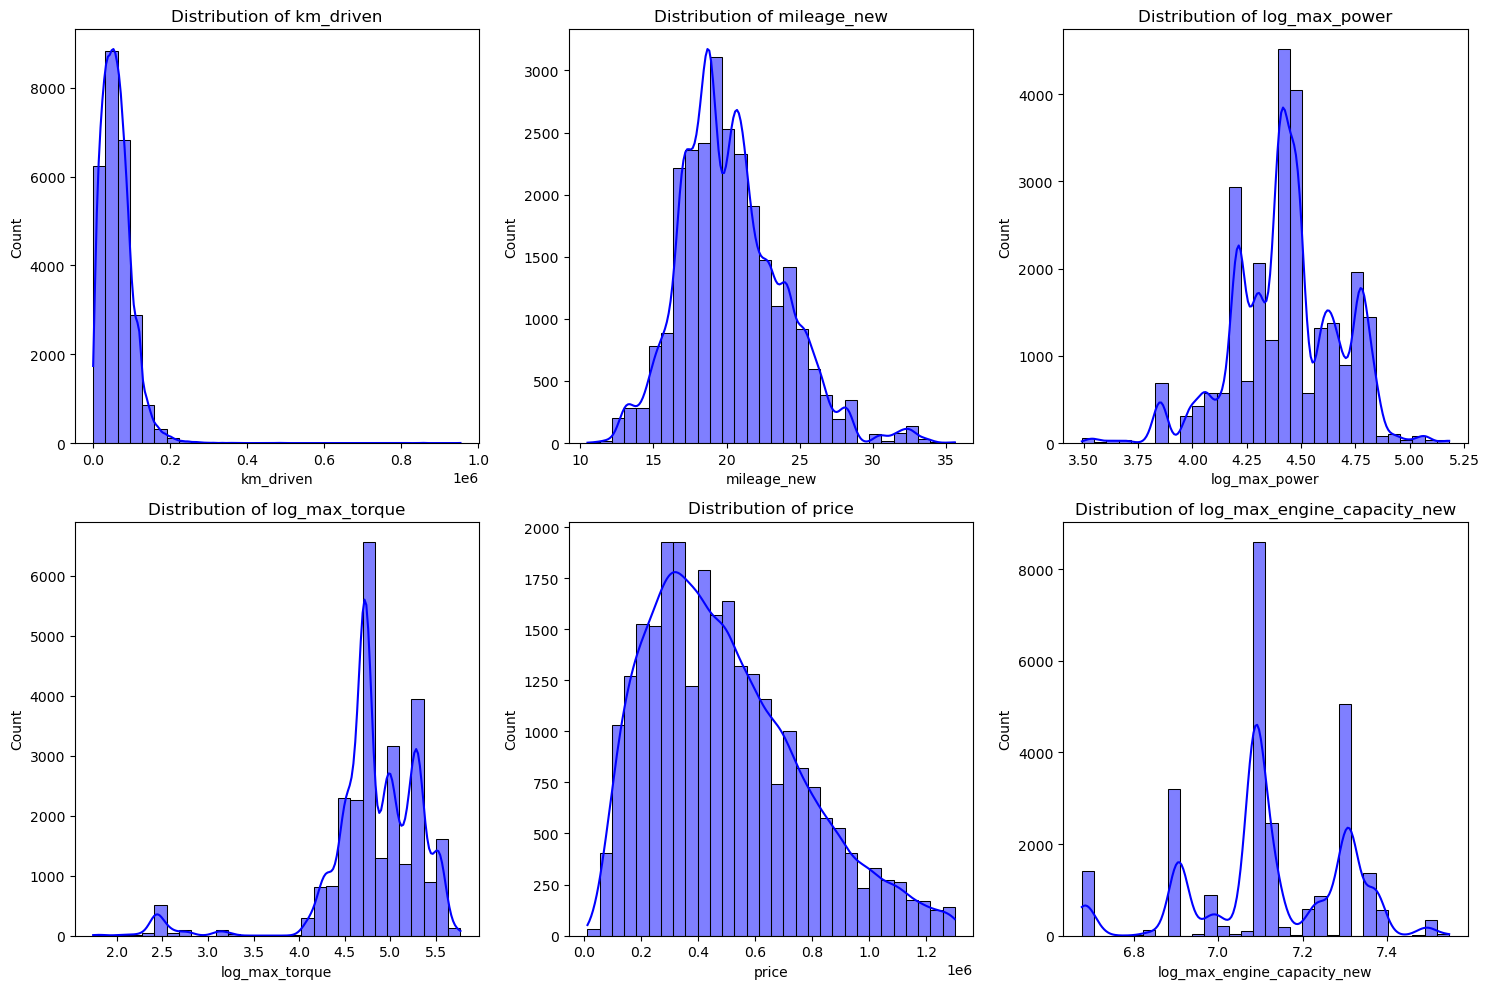

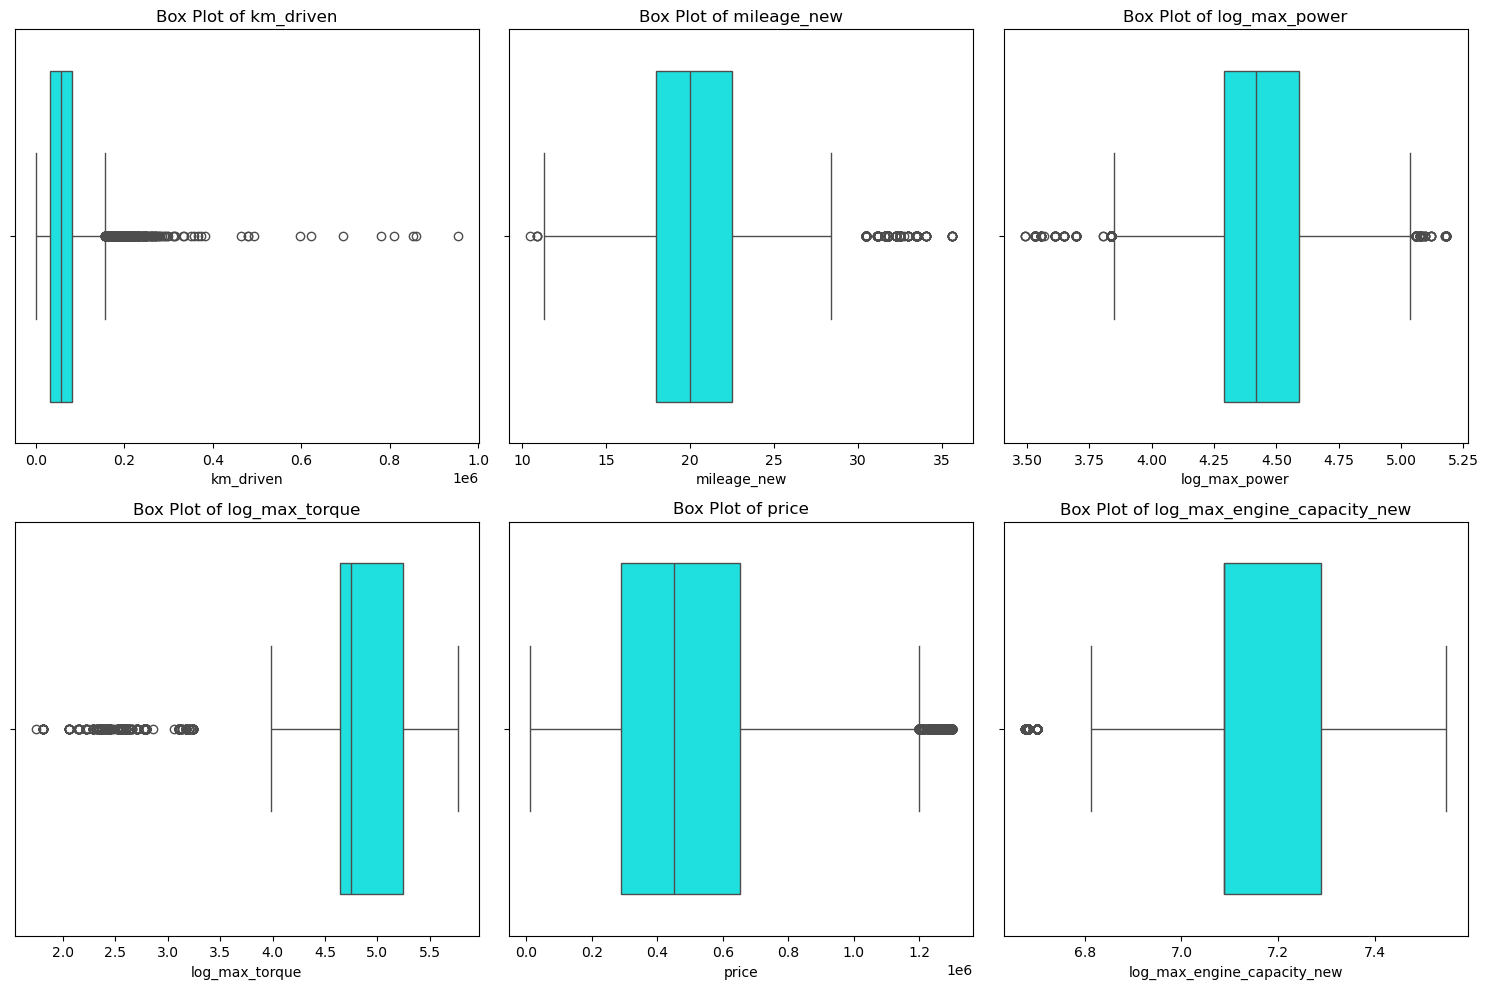

In [ ]:
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]



# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

Testing model with 3 hidden layers and 128 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 3, Neurons: 128, Train MSE: 4556533.00, Val MSE: 1854066.25
Testing model with 3 hidden layers and 180 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 3, Neurons: 180, Train MSE: 494475.44, Val MSE: 196255.41
Testing model with 3 hidden layers and 256 neurons


...

Layers: 5, Neurons: 128, Train MSE: 131345.61, Val MSE: 331460.19
Testing model with 5 hidden layers and 180 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 5, Neurons: 180, Train MSE: 206113.14, Val MSE: 140158.52
Testing model with 5 hidden layers and 256 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 5, Neurons: 256, Train MSE: 821109.12, Val MSE: 180510.58


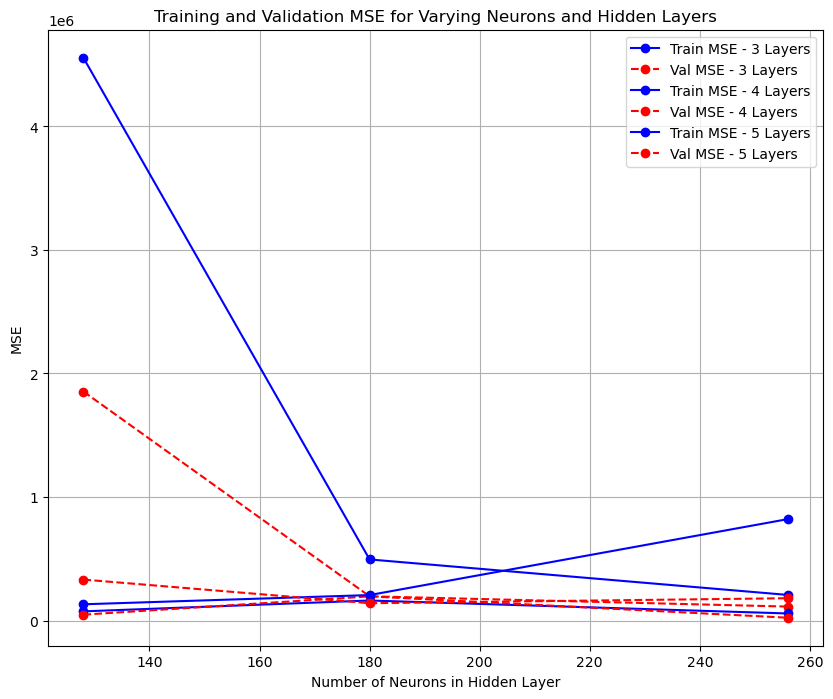

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define neuron configurations (4 different numbers of neurons)
neuron_no = [ 64, 128, 180 , 256]  # Neurons
layer_no = [ 2, 3, 4,5, 6  ]  # Number of hidden layers

mse_train = {layers: [] for layers in layer_no}  # Store training MSE for each layer configuration
mse_val = {layers: [] for layers in layer_no}  # Store validation MSE for each layer configuration

# Loop over different numbers of hidden layers (1, 2, 3, 4 layers)
for layers in layer_no:
    for neurons in neuron_no:
        print(f"Testing model with {layers} hidden layers and {neurons} neurons")
        
        # Build the model with the specified number of hidden layers and neurons
        model = Sequential()
        model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))  # Input + 1st hidden layer
        for _ in range(layers - 1):  # Add additional hidden layers
            model.add(Dense(neurons, activation='relu'))
        model.add(Dense(1))  # Output layer for regression
        
        # Compile and train the model
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=0)

        # Store the MSE for both training and validation
        mse_train[layers].append(history.history['loss'][-1])  # Last epoch training MSE
        mse_val[layers].append(history.history['val_loss'][-1])  # Last epoch validation MSE
        print(f"Layers: {layers}, Neurons: {neurons}, Train MSE: {mse_train[layers][-1]:.2f}, Val MSE: {mse_val[layers][-1]:.2f}")

# Plot MSE for both training and validation for each configuration
plt.figure(figsize=(10, 8))

# Plot for each layer configuration
for layers in layer_no:
    plt.plot(neuron_no, mse_train[layers], marker='o', label=f'Train MSE - {layers} Layers', linestyle='-', color='blue')
    plt.plot(neuron_no, mse_val[layers], marker='o', label=f'Val MSE - {layers} Layers', linestyle='--', color='red')

plt.title("Training and Validation MSE for Varying Neurons and Hidden Layers")
plt.xlabel("Number of Neurons in Hidden Layer")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model10.save('trained_model.keras')